In [13]:
import pandas as pd

from sklearn.model_selection import train_test_split

from practice1 import randn_arr

df = pd.DataFrame({
    "hours_studied": [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
        11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
        21, 22, 23, 24, 25, 26, 27, 28, 29, 30
    ],

    "marks": [
        35, 39, 43, 47, 51, 55, 59, 62, 66, 69,
        72, 75, 78, 81, 83, 85, 87, 89, 91, 92,
        93, 94, 95, 96, 97, 97, 98, 98, 99, 99
    ]
})

# Features
X = df[["hours_studied"]]

# Target
y = df["marks"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:")
print(X_train)

print("\nX_test:")
print(X_test)

print("\ny_train:")
print(y_train)

print("\ny_test:")
print(y_test)

X_train:
    hours_studied
28             29
24             25
12             13
0               1
4               5
16             17
5               6
13             14
11             12
22             23
1               2
2               3
25             26
3               4
21             22
26             27
18             19
29             30
20             21
7               8
10             11
14             15
19             20
6               7

X_test:
    hours_studied
27             28
15             16
23             24
17             18
8               9
9              10

y_train:
28    99
24    97
12    78
0     35
4     51
16    87
5     55
13    81
11    75
22    95
1     39
2     43
25    97
3     47
21    94
26    98
18    91
29    99
20    93
7     62
10    72
14    83
19    92
6     59
Name: marks, dtype: int64

y_test:
27    98
15    85
23    96
17    89
8     66
9     69
Name: marks, dtype: int64


In [19]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

n_estimators_values = [10, 50, 100, 200]

for n in n_estimators_values:

    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.2,
        max_depth=2,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate error
    mse = mean_squared_error(
        y_test,
        y_pred
    )

    print(f"n_estimators = {n}, MSE = {mse:.2f}")

n_estimators = 10, MSE = 9.40
n_estimators = 50, MSE = 5.48
n_estimators = 100, MSE = 5.62
n_estimators = 200, MSE = 5.66


In [20]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]

for lr in learning_rates:

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        max_depth=2,
        random_state=42
    )

    # Train the model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate error
    mse = mean_squared_error(y_test, y_pred)

    print(f"learning_rate = {lr}, MSE = {mse:.2f}")

learning_rate = 0.01, MSE = 39.63
learning_rate = 0.05, MSE = 5.72
learning_rate = 0.1, MSE = 5.66
learning_rate = 0.5, MSE = 5.67
learning_rate = 1.0, MSE = 5.67


In [21]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

depth_values = [1, 2, 3, 5, 8]

for depth in depth_values:

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42
    )

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate error
    mse = mean_squared_error(
        y_test,
        y_pred
    )

    print(
        f"max_depth = {depth}, "
        f"MSE = {mse:.2f}"
    )

max_depth = 1, MSE = 5.26
max_depth = 2, MSE = 5.66
max_depth = 3, MSE = 5.67
max_depth = 5, MSE = 5.67
max_depth = 8, MSE = 5.67


In [26]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
model=GradientBoostingRegressor(

    n_estimators=200,
    learning_rate=0.1,
    max_depth=2,
random_state=42
)

In [28]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [30]:
train_errors = []
test_errors = []

for train_prediction, test_prediction in zip(
    model.staged_predict(X_train),
    model.staged_predict(X_test)
):

    train_mse = mean_squared_error(
        y_train,
        train_prediction
    )

    test_mse = mean_squared_error(
        y_test,
        test_prediction
    )

    train_errors.append(train_mse)
    test_errors.append(test_mse)
    print("train_mse:", train_mse)
    print("test_mse:", test_mse)

train_mse: 361.5489185606062
test_mse: 176.42458667355376
train_mse: 295.6335003300048
test_mse: 149.4709689020891
train_mse: 242.1345155455614
test_mse: 124.20198120940891
train_mse: 198.42707573201997
test_mse: 103.76704135260913
train_mse: 162.9506697221473
test_mse: 89.78095484549173
train_mse: 133.94698401005965
test_mse: 74.62453191524035
train_mse: 109.9879351718301
test_mse: 61.787109758081606
train_mse: 90.46207242728933
test_mse: 51.41142864042891
train_mse: 74.41589867562637
test_mse: 42.4765250583957
train_mse: 61.34632154990563
test_mse: 36.91786773170423
train_mse: 50.58569744317038
test_mse: 31.584457996347307
train_mse: 41.61215348188053
test_mse: 26.748882757012908
train_mse: 34.28182890546723
test_mse: 23.009701819918032
train_mse: 28.30498700573825
test_mse: 21.06759631108449
train_mse: 23.372663033841988
test_mse: 18.431561994639004
train_mse: 19.28423494644665
test_mse: 16.80637861940394
train_mse: 15.946277281073774
test_mse: 14.804360540811516
train_mse: 13.18925

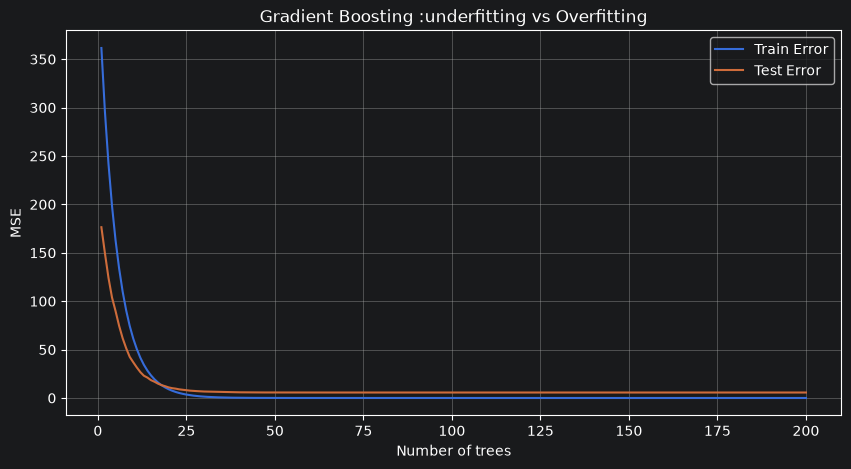

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(range(1,201),train_errors,label="Train Error")

plt.plot(range(1,201),test_errors,label="Test Error")
plt.xlabel("Number of trees")
plt.ylabel("MSE")
plt.title("Gradient Boosting :underfitting vs Overfitting")
plt.legend()
plt.grid()
plt.show()